# 1 — IMPORTS

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 2 — DOWNLOAD DATA AGAIN

In [2]:
stocks = {
    "Reliance": "RELIANCE.NS",
    "Infosys": "INFY.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "Tata Steel": "TATASTEEL.NS",
    "Sun Pharma": "SUNPHARMA.NS"
}

stock_data = {}

for name, ticker in stocks.items():

    data = yf.download(
        ticker,
        start="2021-01-01",
        end="2025-12-31",
        interval="1d",
        auto_adjust=False
    )

    # Remove multi-level columns
    data.columns = data.columns.get_level_values(0)

    stock_data[name] = data

print("\n All datasets loaded successfully!")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


 All datasets loaded successfully!


In [3]:
for name, data in stock_data.items():

    print(f"\n{name}")
    print(data.columns)


Reliance
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

Infosys
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

HDFC Bank
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

Tata Steel
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

Sun Pharma
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


# 3 — CALCULATE RETURNS & VOLATILITY

In [4]:
volatility_dict = {}

for name, data in stock_data.items():

    returns = data['Close'].pct_change().dropna()

    volatility = returns.std()

    volatility_dict[name] = volatility

volatility_df = pd.DataFrame.from_dict(
    volatility_dict,
    orient='index',
    columns=['Volatility']
)

volatility_df

,Volatility
Reliance,0.014315
Infosys,0.015213
HDFC Bank,0.013410
Tata Steel,0.020843
Sun Pharma,0.013191


# 4 — INVERSE VOLATILITY WEIGHTS

In [5]:
inverse_volatility = 1 / volatility_df['Volatility']

weights = inverse_volatility / inverse_volatility.sum()

volatility_df['Weight'] = weights

volatility_df

,Volatility,Weight
Reliance,0.014315,0.209189
Infosys,0.015213,0.196837
HDFC Bank,0.013410,0.223296
Tata Steel,0.020843,0.143671
Sun Pharma,0.013191,0.227006


# 5 — CAPITAL ALLOCATION

In [6]:
capital = 1000000

volatility_df['Allocation'] = (
    volatility_df['Weight'] * capital
)

volatility_df

,Volatility,Weight,Allocation
Reliance,0.014315,0.209189,209188.789493
Infosys,0.015213,0.196837,196837.499575
HDFC Bank,0.013410,0.223296,223296.397160
Tata Steel,0.020843,0.143671,143670.971208
Sun Pharma,0.013191,0.227006,227006.342564


# 6 — CREATE RETURNS DATAFRAME

In [7]:
returns_df = pd.DataFrame()

for name, data in stock_data.items():

    returns_df[name] = data['Close'].pct_change()

returns_df = returns_df.dropna()

returns_df.head()

,Reliance,Infosys,HDFC Bank,Tata Steel,Sun Pharma
Date,,,,,
2021-01-04,0.001686,0.022056,-0.006351,0.077593,0.013669
2021-01-05,-0.012432,0.004308,0.007556,-0.017965,-0.001572
2021-01-06,-0.026372,-0.009043,-0.004311,0.004776,0.003066
2021-01-07,-0.001619,-0.015560,-0.003027,0.057034,-0.005617
2021-01-08,0.011799,0.039575,0.010874,-0.013351,0.031401


# 7 — CORRELATION MATRIX

In [8]:
correlation_matrix = returns_df.corr()

correlation_matrix

,Reliance,Infosys,HDFC Bank,Tata Steel,Sun Pharma
Reliance,1.000000,0.273972,0.363722,0.390913,0.232326
Infosys,0.273972,1.000000,0.258397,0.240660,0.205603
HDFC Bank,0.363722,0.258397,1.000000,0.297971,0.186725
Tata Steel,0.390913,0.240660,0.297971,1.000000,0.297680
Sun Pharma,0.232326,0.205603,0.186725,0.297680,1.000000


# 8 — HEATMAP VISUALIZATION

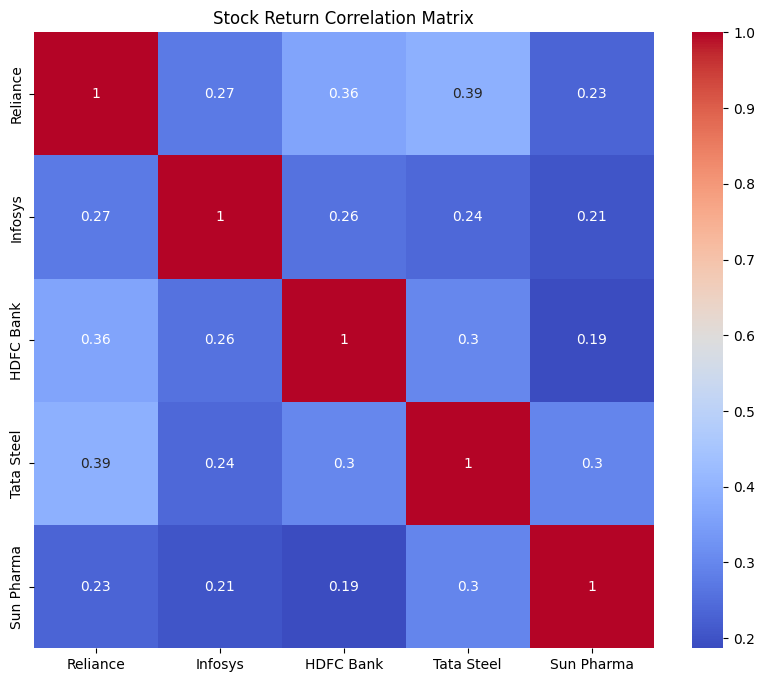

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Stock Return Correlation Matrix")

plt.show()

# 9 — ADD SECTOR INFO

In [10]:
sector_info = {
    "Reliance": "Energy",
    "Infosys": "IT",
    "HDFC Bank": "Banking",
    "Tata Steel": "Metals",
    "Sun Pharma": "Pharma"
}

volatility_df['Sector'] = volatility_df.index.map(sector_info)

volatility_df

,Volatility,Weight,Allocation,Sector
Reliance,0.014315,0.209189,209188.789493,Energy
Infosys,0.015213,0.196837,196837.499575,IT
HDFC Bank,0.013410,0.223296,223296.397160,Banking
Tata Steel,0.020843,0.143671,143670.971208,Metals
Sun Pharma,0.013191,0.227006,227006.342564,Pharma


# 10 FINAL PORTFOLIO WEIGHTS

In [11]:
final_weights = {
    "Reliance": 0.24,
    "Infosys": 0.20,
    "HDFC Bank": 0.28,
    "Tata Steel": 0.12,
    "Sun Pharma": 0.16
}

# 11 — FINAL PORTFOLIO TABLE

In [12]:
capital = 1000000

portfolio_df = pd.DataFrame.from_dict(
    final_weights,
    orient='index',
    columns=['Weight']
)

portfolio_df['Allocation'] = (
    portfolio_df['Weight'] * capital
)

portfolio_df['Sector'] = portfolio_df.index.map(sector_info)

portfolio_df

,Weight,Allocation,Sector
Reliance,0.24,240000.0,Energy
Infosys,0.20,200000.0,IT
HDFC Bank,0.28,280000.0,Banking
Tata Steel,0.12,120000.0,Metals
Sun Pharma,0.16,160000.0,Pharma


# PIE CHART — PORTFOLIO ALLOCATION

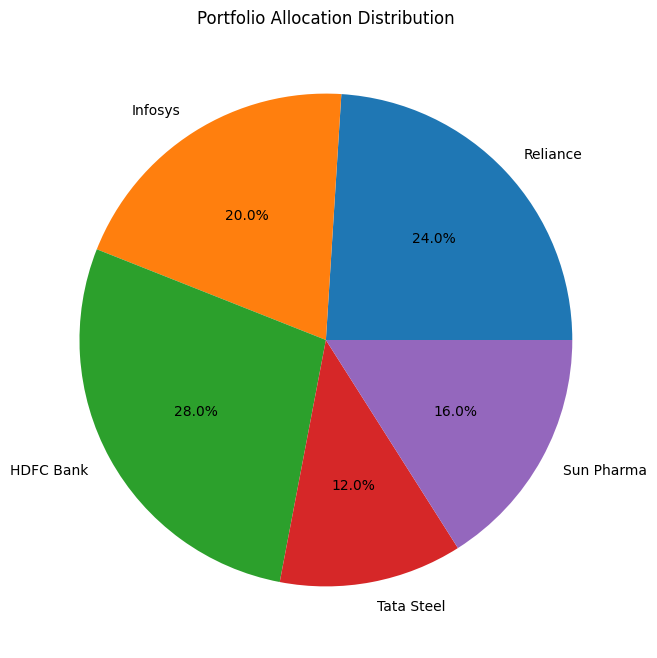

In [13]:
plt.figure(figsize=(8,8))

plt.pie(
    portfolio_df['Allocation'],
    labels=portfolio_df.index,
    autopct='%1.1f%%'
)

plt.title("Portfolio Allocation Distribution")

plt.show()

# BAR CHART — CAPITAL ALLOCATION

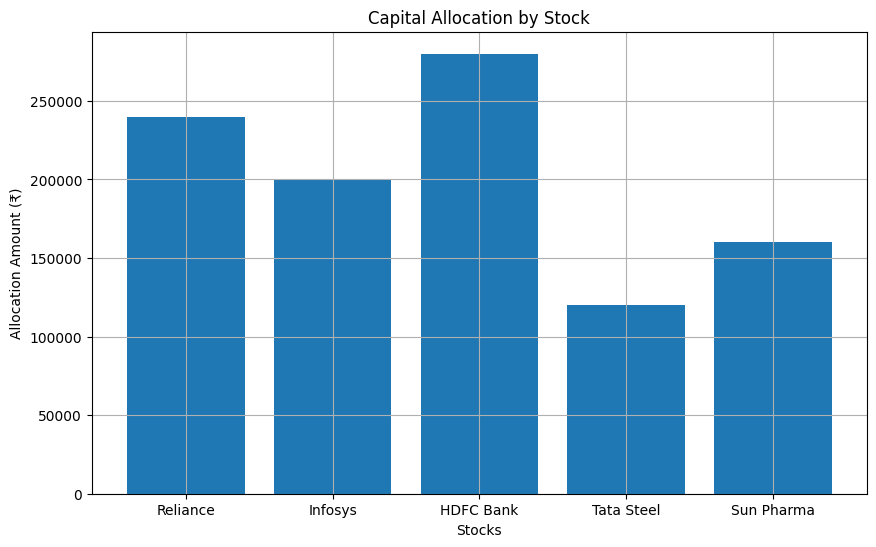

In [14]:
plt.figure(figsize=(10,6))

plt.bar(
    portfolio_df.index,
    portfolio_df['Allocation']
)

plt.title("Capital Allocation by Stock")

plt.xlabel("Stocks")
plt.ylabel("Allocation Amount (₹)")

plt.grid(True)

plt.show()

# SECTOR DISTRIBUTION

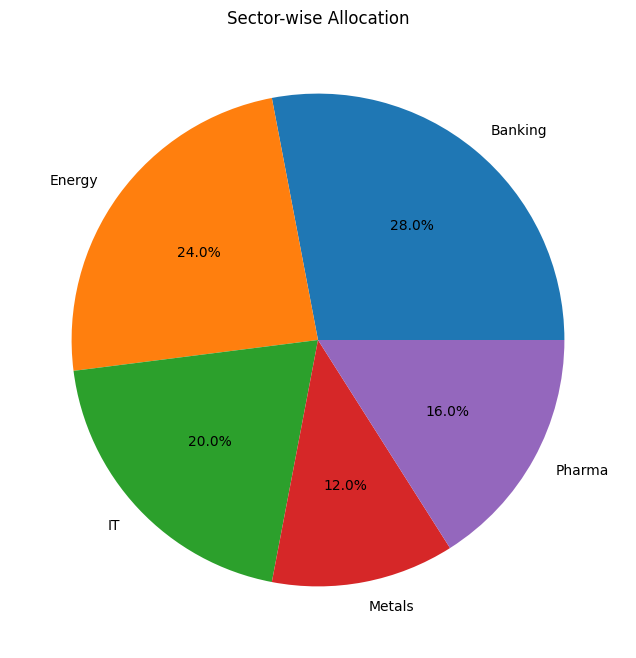

In [15]:
sector_allocation = portfolio_df.groupby(
    'Sector'
)['Allocation'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct='%1.1f%%'
)

plt.title("Sector-wise Allocation")

plt.show()